In [61]:
import numpy as np
import matplotlib.pyplot as plt
import ising

from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorSampler, StatevectorEstimator

from scipy.optimize import minimize
from dataclasses import dataclass

In [68]:
n_qubits = 3
field_str = 0.433

magnetization = ising.gen_magnetization_op(n_qubits)
hamiltonian = ising.gen_hamiltonian_op(field=field_str, coupling=1.0, n_qubits=n_qubits)
hamiltonian

SparsePauliOp(['XII', 'IXI', 'IIX', 'ZZI', 'IZZ', 'ZIZ'],
              coeffs=[-0.433+0.j, -0.433+0.j, -0.433+0.j, -1.   +0.j, -1.   +0.j, -1.   +0.j])

In [69]:
eigenvalues, eigenvectors = np.linalg.eigh(np.array(hamiltonian))
e_gs = min(eigenvalues)
print("The ground state energy is ", e_gs)

The ground state energy is  -3.1702265252407362


This circuit has  18 parameters


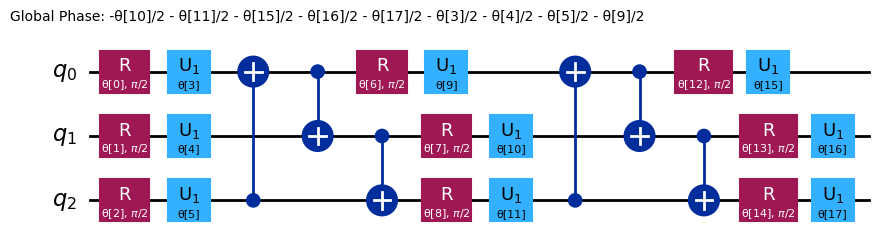

In [70]:
ansatz = efficient_su2(
    hamiltonian.num_qubits, entanglement="circular", reps=2
)

num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")

ansatz.decompose().draw("mpl")

In [71]:
def compute_expectation(params, ansatz, operator):
    pub = (ansatz, [operator], [params])

    # Get the expected value of X
    estimator = StatevectorEstimator()
    job = estimator.run([pub])
    result = job.result()[0]

    return result.data.evs.item()

In [72]:
@dataclass
class OptResult:
    energy : float
    magnetization : float

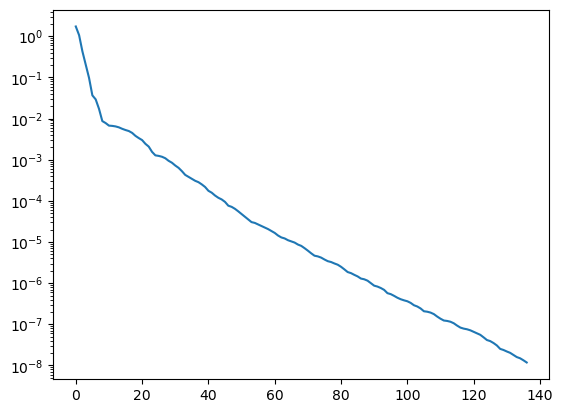

In [73]:
x0 = 2 * np.pi * np.random.rand(num_params)

cost_hist = []
optimization_result = minimize(
    compute_expectation, x0, args=(ansatz, hamiltonian), method="BFGS", 
    callback=lambda intermediate_result: cost_hist.append(intermediate_result.fun)
    )

cost_hist = np.array(cost_hist)

res = OptResult(
    compute_expectation(optimization_result.x, ansatz, hamiltonian),
    compute_expectation(optimization_result.x, ansatz, magnetization)
    )

plt.plot(cost_hist - e_gs)
plt.yscale("log")

In [74]:
res

OptResult(energy=-3.1702265134466217, magnetization=-0.002641466487792732)

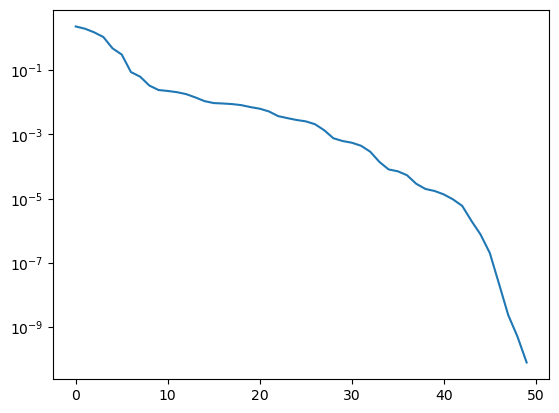